# Retail Sales Analytics Dashboard

## Project Overview

This project analyzes retail sales data using Exploratory Data Analysis,
Machine Learning, Customer Segmentation, and Product Performance Analysis.

### Objectives
- Analyze retail sales trends
- Predict sales using Machine Learning
- Segment customers using RFM and K-Means
- Analyze product sales and profitability
- Analyze product return rates
- Generate actionable business insights

# 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Load Dataset

In [3]:
df_raw = pd.read_csv("sales.csv")

print("Dataset Shape:", df_raw.shape)
df_raw.head()

Dataset Shape: (10100, 28)


,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Name,Gender,Age,Email,Phone,Region,...,Discount,Sales,Cost,Profit,Payment_Mode,Order_Priority,Customer_Segment,Delivery_Days,Customer_Rating,Returned
0,ORD000004,03-07-2022,06-07-2022,CUST00945,Logan Khosla,Male,19,uppaltarak@example.net,1.050097e+09,West,...,30.0,193235.7,213311.48,-20075.78,Cash,Medium,Corporate,3,4.0,No
1,ORD000005,20-03-2023,21-03-2023,CUST00560,Tamanna Halder,Female,53,hemal72@example.net,1.918315e+08,North,...,15.0,243780.0,218272.56,25507.44,Cash,High,Regular,1,1.0,Yes
2,ORD000006,01-09-2024,04-09-2024,CUST02577,Noah Sem,Male,20,imaranben@example.org,8.319264e+09,North,...,15.0,69628.6,69590.62,37.98,Credit Card,High,Regular,3,4.0,No
3,ORD000007,23-01-2024,25-01-2024,CUST01069,Onkar Edwin,Male,51,xhalder@example.org,9.195530e+11,North,...,20.0,89200.0,90045.00,-845.00,Net Banking,Medium,Corporate,2,1.0,Yes
4,ORD000008,13-07-2022,14-07-2022,CUST03566,Nachiket Prabhakar,Male,25,ichand@example.net,8.035514e+09,North,...,15.0,137098.2,135832.23,1265.97,Cash,Critical,Regular,1,2.0,Yes


# 4. Data Understanding

In [4]:
df_raw.head()
df_raw.shape
df_raw.info()
df_raw.columns
df_raw.describe()
df_raw.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10100 non-null  object 
 1   Order_Date        10100 non-null  object 
 2   Ship_Date         10100 non-null  object 
 3   Customer_ID       10100 non-null  object 
 4   Customer_Name     10100 non-null  object 
 5   Gender            10100 non-null  object 
 6   Age               10100 non-null  int64  
 7   Email             9899 non-null   object 
 8   Phone             9899 non-null   float64
 9   Region            10100 non-null  object 
 10  State             10100 non-null  object 
 11  City              10100 non-null  object 
 12  Product_ID        10100 non-null  object 
 13  Product_Name      10100 non-null  object 
 14  Category          10100 non-null  object 
 15  Brand             10100 non-null  object 
 16  Quantity          10100 non-null  int64 

Order_ID             object
Order_Date           object
Ship_Date            object
Customer_ID          object
Customer_Name        object
Gender               object
Age                   int64
Email                object
Phone               float64
Region               object
State                object
City                 object
Product_ID           object
Product_Name         object
Category             object
Brand                object
Quantity              int64
Unit_Price            int64
Discount            float64
Sales               float64
Cost                float64
Profit              float64
Payment_Mode         object
Order_Priority       object
Customer_Segment     object
Delivery_Days         int64
Customer_Rating     float64
Returned             object
dtype: object

# 5. Data Cleaning

## 5.1 Missing Value Analysis

In [5]:
df_raw.isnull().sum()

Order_ID              0
Order_Date            0
Ship_Date             0
Customer_ID           0
Customer_Name         0
Gender                0
Age                   0
Email               201
Phone               201
Region                0
State                 0
City                  0
Product_ID            0
Product_Name          0
Category              0
Brand                 0
Quantity              0
Unit_Price            0
Discount            201
Sales                 0
Cost                  0
Profit                0
Payment_Mode          0
Order_Priority        0
Customer_Segment      0
Delivery_Days         0
Customer_Rating     201
Returned              0
dtype: int64

## 5.2 Date Conversion


In [6]:
df_raw['Order_Date'] = pd.to_datetime(
    df_raw['Order_Date'],
    format='%d-%m-%Y'
)

## 5.3 Duplicate Record Analysis

In [7]:
print("Exact duplicate rows:", df_raw.duplicated().sum())

print(
    "Duplicate Order_ID records:",
    df_raw['Order_ID'].duplicated().sum()
)

Exact duplicate rows: 98
Duplicate Order_ID records: 100


## 5.4 Duplicate Removal and Data Validation

In [8]:
## clean data
df_clean = df_raw.drop_duplicates().copy()

print("Rows after removing exact duplicates:", len(df_clean))
print("Unique Order IDs:", df_clean['Order_ID'].nunique())

Rows after removing exact duplicates: 10002
Unique Order IDs: 10000


In [ ]:
## ORD007537

row = df_clean[df_clean['Order_ID'] == 'ORD007537'].copy()

row['Expected_Sales'] = (
    row['Quantity'] *
    row['Unit_Price'] *
    (1 - row['Discount'] / 100)
)

print(
    row[
        ['Order_ID', 'Quantity', 'Unit_Price',
         'Discount', 'Sales', 'Expected_Sales']
    ]
)

##removing inconsistent record
df_clean = df_clean.drop(
    df_clean[
        (df_clean['Order_ID'] == 'ORD007537') &
        (df_clean['Sales'] == 1746900.00)
    ].index
)

print("Final rows:", len(df_clean))
print("Unique orders:", df_clean['Order_ID'].nunique())
print(
    "Duplicate Order IDs:",
    df_clean['Order_ID'].duplicated().sum()
)

        Order_ID  Quantity  Unit_Price  Discount     Sales  Expected_Sales
10017  ORD007537         9       32350      25.0  218362.5        218362.5
Final rows: 10001
Unique orders: 10000
Duplicate Order IDs: 1


In [21]:
# df_clean = df_clean.drop(
#     df_clean[
#         (df_clean['Order_ID'] == 'ORD007537') &
#         (df_clean['Sales'] == 1746900.00)
#     ].index
# )
# print("Final rows:", len(df_clean))
# print("Unique orders:", df_clean['Order_ID'].nunique())
# print(
#     "Duplicate Order IDs:",
#     df_clean['Order_ID'].duplicated().sum()
# )

# df_clean[df_clean['Order_ID'] == 'ORD007537'][
#     ['Order_ID', 'Quantity', 'Unit_Price', 'Discount', 'Sales']
# ]
# df_clean[df_clean['Order_ID'] == 'ORD007537'].index

# duplicates = df_clean[
#     df_clean['Order_ID'].duplicated(keep=False)
# ].sort_values('Order_ID')


# duplicates[['Order_ID', 'Product_Name', 'Sales', 'Returned']]

#df_clean = df_clean.drop(index=10016)
print("Final rows:", len(df_clean))
print("Unique orders:", df_clean['Order_ID'].nunique())
print(
    "Duplicate Order IDs:",
    df_clean['Order_ID'].duplicated().sum()
)


Final rows: 10000
Unique orders: 10000
Duplicate Order IDs: 0


### 5.5 Handling Missing Values

In [ ]:
missing =  df_clean.isnull().sum()
missing[missing>0]

## handle discount
median_discount = df_clean['Discount'].median()

df_clean['Discount'] = df_clean['Discount'].fillna(median_discount)

print("Median Discount:", median_discount)

## handle customer rating
median_rating = df_clean['Customer_Rating'].median()

df_clean['Customer_Rating'] = df_clean['Customer_Rating'].fillna(median_rating)

print("Median Customer Rating:", median_rating)


## handle missing email
df_clean['Email'] = df_clean['Email'].fillna('Not Provided')

##print("Missing Email:", df_clean['Email'].isnull().sum())

## handle mmissing phone 
df_clean['Phone'] = df_clean['Phone'].fillna(0)
print("Missing Phone:", df_clean['Phone'].isnull().sum())

Series([], dtype: int64)

In [41]:
df_clean = df_clean.reset_index(drop=True)
print(df_clean.index)
df_clean.dtypes
df_clean['Ship_Date'] = pd.to_datetime(
    df_clean['Ship_Date'],
    format='%d-%m-%Y'
)
print(df_clean[['Order_Date', 'Ship_Date']].dtypes)

RangeIndex(start=0, stop=10000, step=1)
Order_Date    datetime64[ns]
Ship_Date     datetime64[ns]
dtype: object


In [48]:
##Checkinng Invalid Ages

df_clean['Age'].describe()

invalid_age = df_clean[df_clean['Age'] < 0]

print("Invalid age records:", len(invalid_age))
invalid_age[['Customer_ID', 'Customer_Name', 'Age']]

# Replace invalid ages with NaN
df_clean.loc[df_clean['Age'] < 0, 'Age'] = np.nan

print("Invalid ages replaced:", df_clean['Age'].isnull().sum())

##Filling those 29 ages with median age

median_age = df_clean['Age'].median()

df_clean['Age'] = df_clean['Age'].fillna(median_age)

print("Median Age:", median_age)
print("Missing Age:", df_clean['Age'].isnull().sum())

Invalid age records: 0
Invalid ages replaced: 0
Median Age: 44.0
Missing Age: 0


In [53]:
## Check Invalide Quantity
df_clean['Quantity'].describe()

df_clean['Unit_Price'].describe()

df_clean['Discount'].describe()

df_clean['Sales'].describe()

count    1.000000e+04
mean     2.601516e+05
std      3.890599e+05
min      1.148350e+03
25%      5.878600e+04
50%      1.396191e+05
75%      3.017632e+05
max      9.400326e+06
Name: Sales, dtype: float64

# df_clean status now 
| Check                          | Result                     |
| ------------------------------ | -------------------------- |
| Rows                           | 10,000                     |
| Unique Order IDs               | 10,000                     |
| Duplicate Order IDs            | 0                          |
| Missing values                 | 0                          |
| Discount missing values        | Filled with 10.0           |
| Customer Rating missing values | Filled with 3.0            |
| Email missing values           | Filled with `Not Provided` |
| Phone missing values           | Filled with `0`            |


# 6. Exploratory Data Analysis

## 6.1 Monthly Sales Trend

<Figure size 1000x600 with 0 Axes>

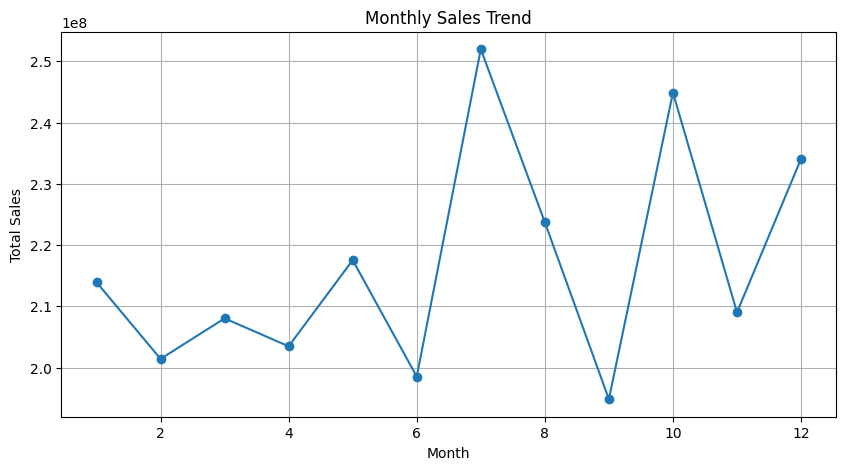

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
monthly_sales = df_clean.groupby('Month')['Sales'].sum().reset_index()
monthly_sales
plt.figure(figsize=(10,5))

plt.plot(monthly_sales['Month'],
         monthly_sales['Sales'],
         marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)
plt.show()

## 6.2 Sales by Category

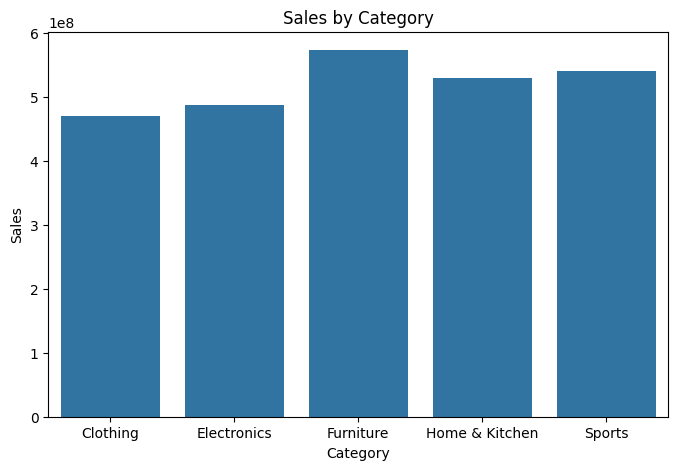

In [55]:
category_sales = df_clean.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(data=category_sales,
            x='Category',
            y='Sales')

plt.title("Sales by Category")
plt.show()

## 6.3  Profit by Category

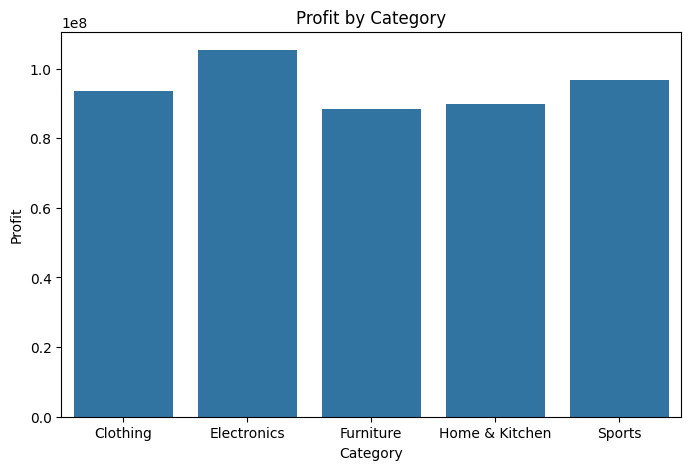

In [56]:
category_profit = df_clean.groupby('Category')['Profit'].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(data=category_profit,
            x='Category',
            y='Profit')

plt.title("Profit by Category")
plt.show()

## 6.4 Top 10 Products by Sales

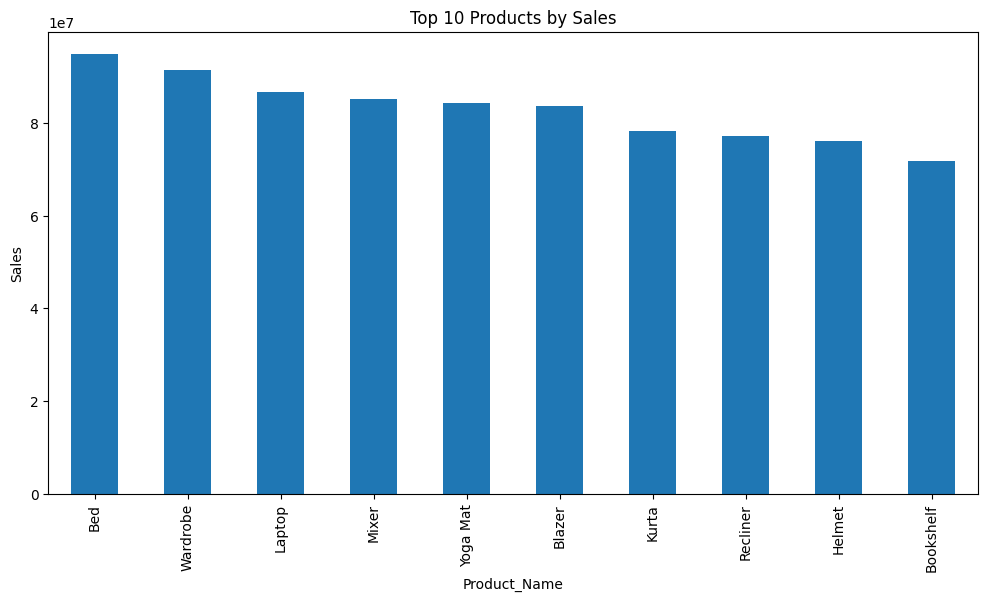

In [57]:
top_products = df_clean.groupby('Product_Name')['Sales'].sum().nlargest(10)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")

plt.show()

## 6.5 Sales  By Region

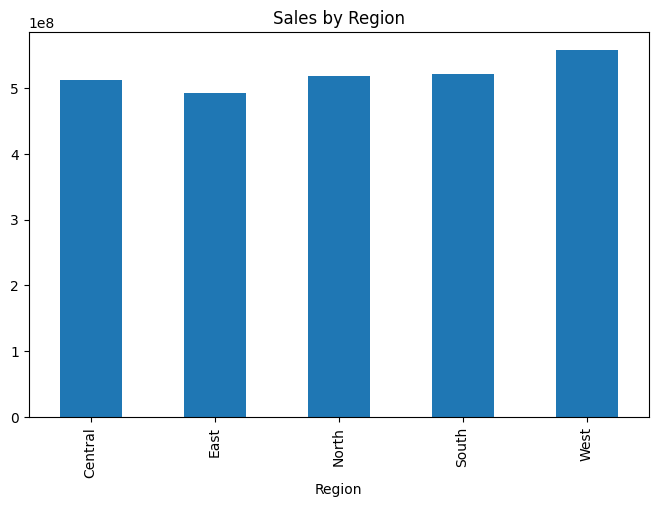

In [58]:
region_sales = df_clean.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Sales by Region")

plt.show()

## 6.6 Correlation Heatmap

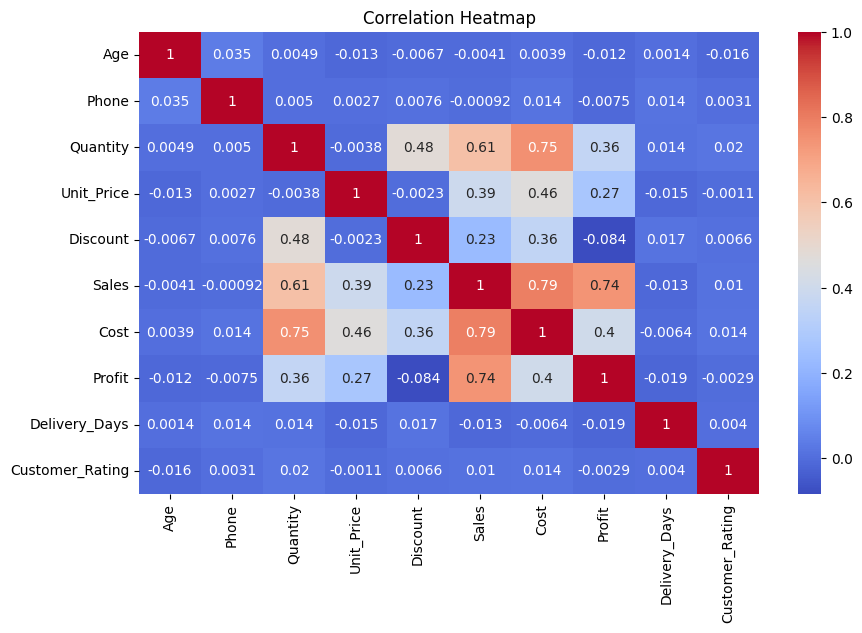

In [59]:
numeric = df_clean.select_dtypes(include='number')
plt.figure(figsize=(10,6))

sns.heatmap(numeric.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

## 6.7 Sales Outliers

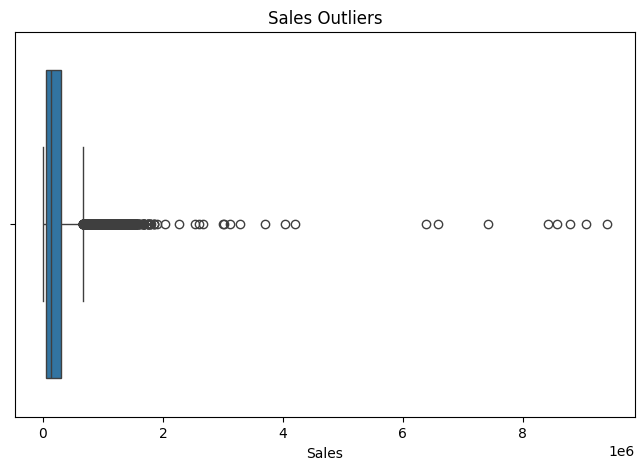

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df_clean['Sales'])

plt.title("Sales Outliers")

plt.show()

In [ ]:
print(df_clean.columns.tolist())

## 7. Feature Engineering

In [61]:
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], dayfirst=True)



df_clean['Order_Date'].dtype



df_clean['Year'] = df_clean['Order_Date'].dt.year



df_clean['Month'] = df_clean['Order_Date'].dt.month



df_clean['Month_Name'] = df_clean['Order_Date'].dt.month_name()



df_clean['Quarter'] = df_clean['Order_Date'].dt.quarter



df_clean['Day'] = df_clean['Order_Date'].dt.day



df_clean['Day_of_Week'] = df_clean['Order_Date'].dt.day_name()



df_clean[['Order_Date', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day_of_Week']].head()

,Order_Date,Year,Month,Month_Name,Quarter,Day_of_Week
0,2022-07-03,2022,7,July,3,Sunday
1,2023-03-20,2023,3,March,1,Monday
2,2024-09-01,2024,9,September,3,Sunday
3,2024-01-23,2024,1,January,1,Tuesday
4,2022-07-13,2022,7,July,3,Wednesday


## 8.Sales Prediction

## 8.1 Preparing Data for Machine Learning

In [64]:
features = [
    'Age',
    'Quantity',
    'Unit_Price',
    'Discount',
    'Delivery_Days',
    'Customer_Rating',
    'Year',
    'Month',
    'Quarter',
    'Gender',
    'Region',
    'Category',
    'Brand',
    'Payment_Mode',
    'Order_Priority',
    'Customer_Segment',
    'Returned'
]

X = df_clean[features]
y = df_clean['Sales']

print(X.shape)
print(y.shape)
X.dtypes

(10000, 17)
(10000,)


Age                 float64
Quantity              int64
Unit_Price            int64
Discount            float64
Delivery_Days         int64
Customer_Rating     float64
Year                  int32
Month                 int32
Quarter               int32
Gender               object
Region               object
Category             object
Brand                object
Payment_Mode         object
Order_Priority       object
Customer_Segment     object
Returned             object
dtype: object

## 8.2 One Hot Encoding for Categorical datas

In [65]:
categorical_cols = [
    'Gender',
    'Region',
    'Category',
    'Brand',
    'Payment_Mode',
    'Order_Priority',
    'Customer_Segment',
    'Returned'
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print(X.shape)
X.head()

(10000, 47)


,Age,Quantity,Unit_Price,Discount,Delivery_Days,Customer_Rating,Year,Month,Quarter,Gender_Male,...,Payment_Mode_Credit Card,Payment_Mode_Debit Card,Payment_Mode_Net Banking,Payment_Mode_UPI,Order_Priority_High,Order_Priority_Low,Order_Priority_Medium,Customer_Segment_Premium,Customer_Segment_Regular,Returned_Yes
0,19.0,19,14529,30.0,3,4.0,2022,7,3,True,...,False,False,False,False,False,False,True,False,False,False
1,53.0,4,71700,15.0,1,1.0,2023,3,1,False,...,False,False,False,False,True,False,False,False,True,True
2,20.0,1,81916,15.0,3,4.0,2024,9,3,True,...,True,False,False,False,True,False,False,False,True,False
3,51.0,20,5575,20.0,2,1.0,2024,1,1,True,...,False,False,True,False,False,False,True,False,False,True
4,25.0,3,53764,15.0,1,2.0,2022,7,3,True,...,False,False,False,False,False,False,False,False,True,True


## 8.3 Train/test Split and Linear Regression evaluation

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Training data:', X_train.shape)
print('Testing data:', X_test.shape)


#HANDLING MISSING VALUES IN DISCOUNT AND CUSTOMER RATING PROBLEM
# X['Discount'] = X['Discount'].fillna(X['Discount'].mean())
# X['Customer_Rating'] = X['Customer_Rating'].fillna(X['Customer_Rating'].mean())

#print(X.isnull().sum())


model = LinearRegression()
model.fit(X_train, y_train)


#COMPARISION WITH PREDICTED MODELS
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

comparison.head(10)

Training data: (8000, 47)
Testing data: (2000, 47)


,Actual Sales,Predicted Sales
6252,103626.00,92364.887817
4684,81355.20,464628.687708
1731,50175.20,10647.261646
4742,276535.50,354349.490288
4521,704789.10,555423.670967
6340,78014.95,335536.003500
576,287193.60,327258.343499
5202,90534.60,105006.236617
6363,1177568.70,868010.456346
439,198060.00,721397.279487


## 8.4 Linear Regression Evaluation

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 109643.03616238064
RMSE: 266867.02290084615
R2 Score: 0.5515082841789742


## 8.5 Random Forest Evaluation

In [68]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

mae_rf= mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2_rf = r2_score(y_test, rf_predictions)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE : 42865.12763625001
RMSE: 271460.1818085787
R2 Score: 0.535937072721548


## 8.6 Model Comparision

| Model             |       MAE |      RMSE |     R² |
| ----------------- | --------: | --------: | -----: |
| Linear Regression |  109643.03616 | 266867.0229| 0.551508 |
| Random Forest     |  42865.13 | 271460.18 | 0.5359 |


# 9.Customer Segmentation

## 9.1 Customer Segmentation and Statistics

In [69]:
reference_date = df_clean['Order_Date'].max() + pd.Timedelta(days=1)

print(reference_date)

rfm = df_clean.groupby('Customer_ID').agg({
    'Order_Date': lambda x: (reference_date - x.max()).days,
    'Order_ID': 'nunique',
    'Sales': 'sum'

})

rfm.rename(columns={
    'Order_Date': 'Recency',
    'Order_ID': 'Frequency',
    'Sales': 'Monetary'
}, inplace=True)

rfm.head()

print(rfm.shape)

print(rfm.describe())
print(rfm.isnull().sum())

rfm.head(10)



2026-01-01 00:00:00
(3673, 3)
           Recency    Frequency      Monetary
count  3673.000000  3673.000000  3.673000e+03
mean    459.715219     2.722570  7.082809e+05
std     373.128769     1.464941  7.447342e+05
min       1.000000     1.000000  1.215900e+03
25%     150.000000     2.000000  2.180654e+05
50%     362.000000     2.000000  4.901634e+05
75%     704.000000     4.000000  1.011088e+06
max    1460.000000    12.000000  1.126997e+07
Recency      0
Frequency    0
Monetary     0
dtype: int64


,Recency,Frequency,Monetary
Customer_ID,,,
CUST00001,177,4,306713.00
CUST00002,11,3,1634188.90
CUST00003,234,2,183462.10
CUST00004,943,1,252081.00
CUST00005,104,6,1300161.25
CUST00006,242,4,380575.40
CUST00007,266,1,80521.05
CUST00008,60,2,260425.70
CUST00010,1131,3,679109.40


## 9.2 Feature Scaling

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()

#print(rfm_scaled.describe())

,Recency,Frequency,Monetary
Customer_ID,,,
CUST00001,-0.757791,0.872120,-0.539283
CUST00002,-1.202738,0.189405,1.243442
CUST00003,-0.605008,-0.493309,-0.704802
CUST00004,1.295399,-1.176024,-0.612651
CUST00005,-0.953461,2.237549,0.794862


## 9.3 K-Means Clustering

### 9.3.1 Elbow Method 

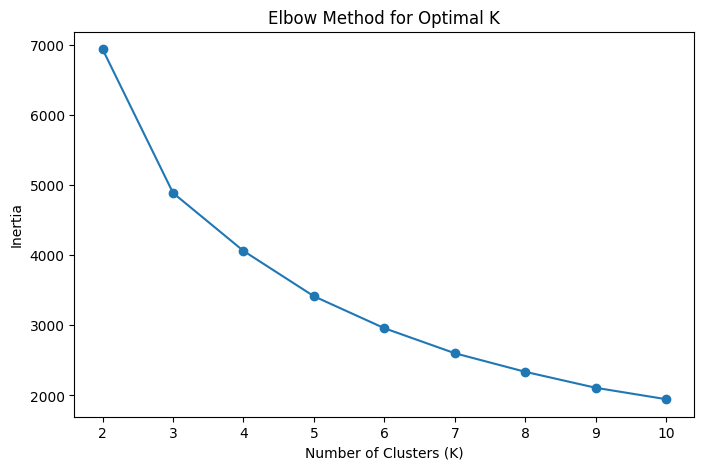

In [71]:
#Elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()    
    

### 9.3.2 Original Perform K- means

In [72]:
#Perform K-means clustering
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())

print(rfm['Cluster'].value_counts().sort_index())

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print(cluster_summary)

cluster_names = {
    0: 'Dormant Customers',
    1: 'Frequent High-Value Customers',
    2: 'VIP Customers',
    3: 'Regular Customers'
}

rfm['Customer_Segment'] = rfm['Cluster'].map(cluster_names)

print(rfm.head())


             Recency  Frequency    Monetary  Cluster
Customer_ID                                         
CUST00001        177          4   306713.00        0
CUST00002         11          3  1634188.90        0
CUST00003        234          2   183462.10        3
CUST00004        943          1   252081.00        1
CUST00005        104          6  1300161.25        0
Cluster
0    1028
1     971
2     261
3    1413
Name: count, dtype: int64
         Recency  Frequency    Monetary
Cluster                                
0         267.22       4.03   996958.45
1         977.54       1.63   408675.09
2         245.40       5.17  2463168.82
3         283.50       2.07   379994.32
             Recency  Frequency    Monetary  Cluster  \
Customer_ID                                            
CUST00001        177          4   306713.00        0   
CUST00002         11          3  1634188.90        0   
CUST00003        234          2   183462.10        3   
CUST00004        943          1   2

## 9.4 Graph Ploting

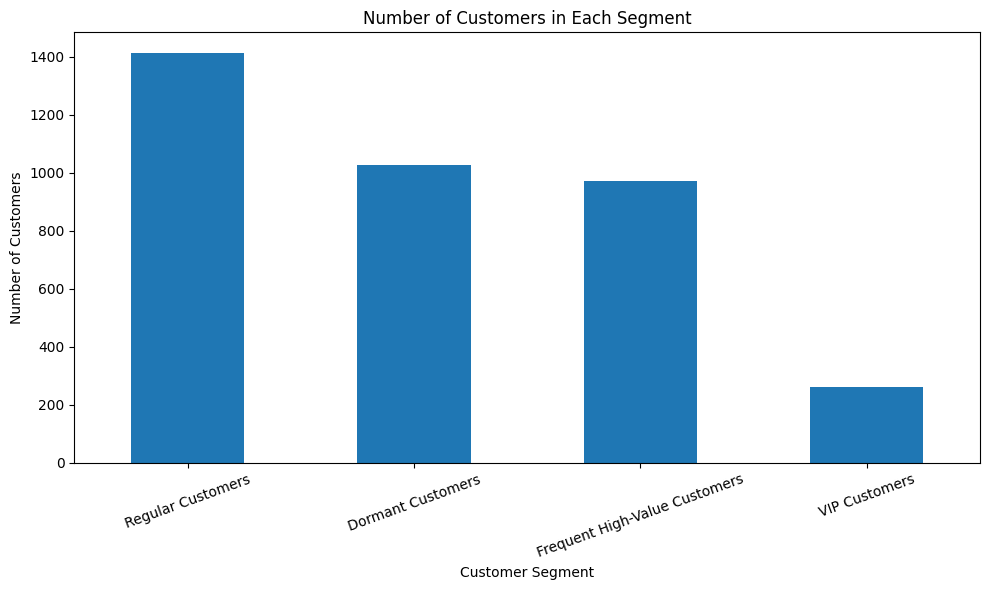

In [73]:
import matplotlib.pyplot as plt

segment_counts = rfm['Customer_Segment'].value_counts()

plt.figure(figsize=(10, 6))

segment_counts.plot(kind='bar')

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Segment')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 9.4.1 Total Sales Contribution by Customer Segment

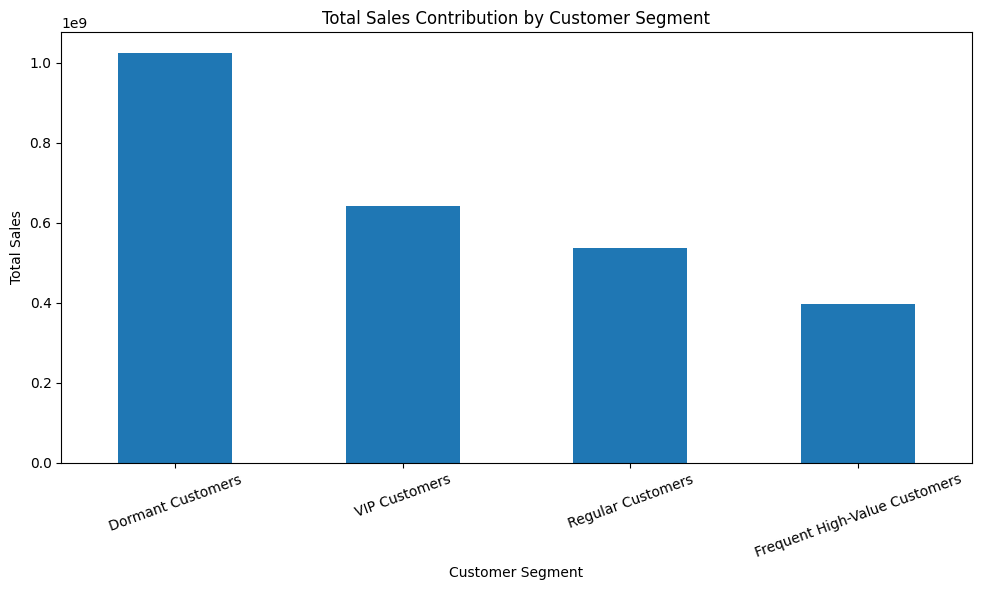

In [74]:
segment_sales = rfm.groupby(
    'Customer_Segment'
)['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

segment_sales.plot(kind='bar')

plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.title('Total Sales Contribution by Customer Segment')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 9.4.2 Customer Segmentation: Frequency vs Monetary

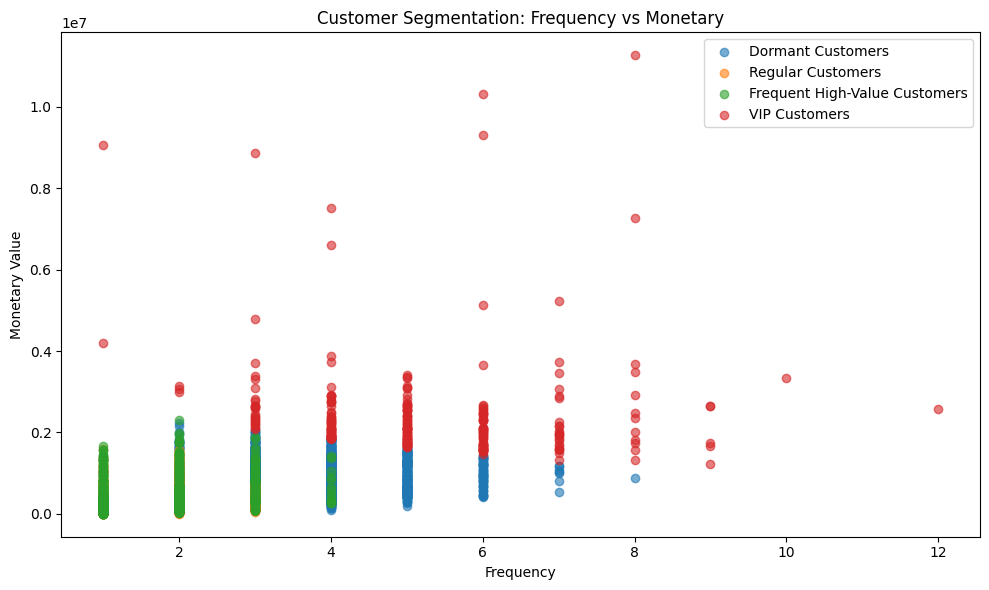

In [75]:
plt.figure(figsize=(10, 6))

for segment in rfm['Customer_Segment'].unique():
    segment_data = rfm[rfm['Customer_Segment'] == segment]
    
    plt.scatter(
        segment_data['Frequency'],
        segment_data['Monetary'],
        label=segment,
        alpha=0.6
    )

plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.title('Customer Segmentation: Frequency vs Monetary')
plt.legend()
plt.tight_layout()
plt.show()

### 9.5 Calculating Customer Percentage

In [76]:
final_segment_summary = rfm.groupby(
    'Customer_Segment'
).agg(
    Customers=('Recency', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Monetary=('Monetary', 'sum')
).round(2)

print(final_segment_summary)



segment_summary = final_segment_summary.copy()

segment_summary['Customer_Percentage'] = (
    segment_summary['Customers'] /
    segment_summary['Customers'].sum() * 100
).round(2)

print(segment_summary)


                               Customers  Avg_Recency  Avg_Frequency  \
Customer_Segment                                                       
Dormant Customers                   1028       267.22           4.03   
Frequent High-Value Customers        971       977.54           1.63   
Regular Customers                   1413       283.50           2.07   
VIP Customers                        261       245.40           5.17   

                               Avg_Monetary  Total_Monetary  
Customer_Segment                                             
Dormant Customers                 996958.45    1.024873e+09  
Frequent High-Value Customers     408675.09    3.968235e+08  
Regular Customers                 379994.32    5.369320e+08  
VIP Customers                    2463168.82    6.428871e+08  
                               Customers  Avg_Recency  Avg_Frequency  \
Customer_Segment                                                       
Dormant Customers                   1028       267.

# 10 Product Performance Analysis

In [79]:
# Product Performance Analysis
top_products_sales = df_clean.groupby('Product_Name')['Sales'].sum().sort_values(
    ascending=False
).head(10)

print(top_products_sales)

top_products_profit = df_clean.groupby('Product_Name')['Profit'].sum().sort_values(
    ascending=False
).head(10)

print(top_products_profit)

product_performance = df_clean.groupby('Product_Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum')
)

product_performance['Profit_Margin'] = (
    product_performance['Total_Profit'] /
    product_performance['Total_Sales'] * 100
).round(2)

print(product_performance.sort_values(
    'Profit_Margin',
    ascending=False
).head(10))



Product_Name
Bed          94945300.20
Wardrobe     91441684.90
Laptop       86577034.70
Mixer        85110090.95
Yoga Mat     84375848.70
Blazer       83688452.40
Kurta        78228624.65
Recliner     77249051.00
Helmet       76164243.90
Bookshelf    71806880.95
Name: Sales, dtype: float64
Product_Name
Blazer               23756479.84
Bed                  22932043.25
Bluetooth Speaker    18030637.00
Laptop               16479538.23
Mixer                15741135.82
Smartphone           14562470.13
Gym Gloves           14545047.74
Track Pant           13909175.36
Wardrobe             13809971.43
Pressure Cooker      13638701.27
Name: Profit, dtype: float64
                   Total_Sales  Total_Profit  Total_Quantity  Profit_Margin
Product_Name                                                               
Smartphone         43959649.80   14562470.13            1190          33.13
Smartwatch         43859344.90   13469743.99            1181          30.71
Badminton Racket   41159498.90   

### 10.1 Product Performance: Sales vs Profit

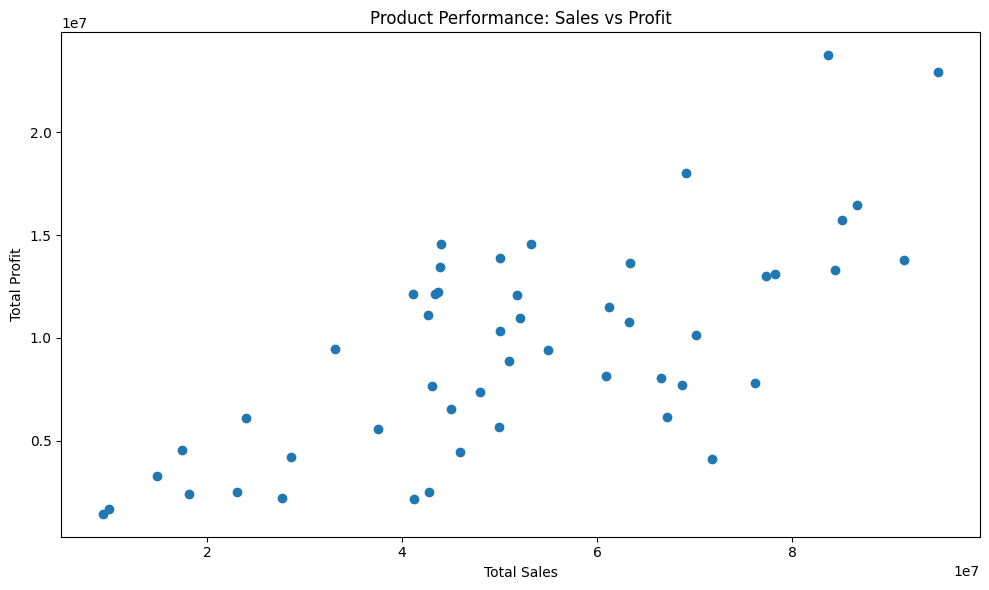

In [80]:
plt.figure(figsize=(10, 6))

plt.scatter(
    product_performance['Total_Sales'],
    product_performance['Total_Profit']
)

plt.xlabel('Total Sales')
plt.ylabel('Total Profit')
plt.title('Product Performance: Sales vs Profit')

plt.tight_layout()
plt.show()

# 11. Return Rate Analysis with Graph

Returned
Yes    5223
No     4777
Name: count, dtype: int64
['No' 'Yes']
Total Records: 10000
Returned Records: 5223
Overall Return Rate: 52.23 %
                 Total_Orders  Returned_Orders  Return_Rate
Product_Name                                               
Bed                       196              116        59.18
Ceiling Fan               204              119        58.33
Gas Stove                 193              112        58.03
TV Unit                   175              101        57.71
Pressure Cooker           184              106        57.61
Gym Gloves                198              114        57.58
Dining Table              205              117        57.07
Sweater                   191              108        56.54
Air Fryer                 200              113        56.50
Skipping Rope             207              116        56.04


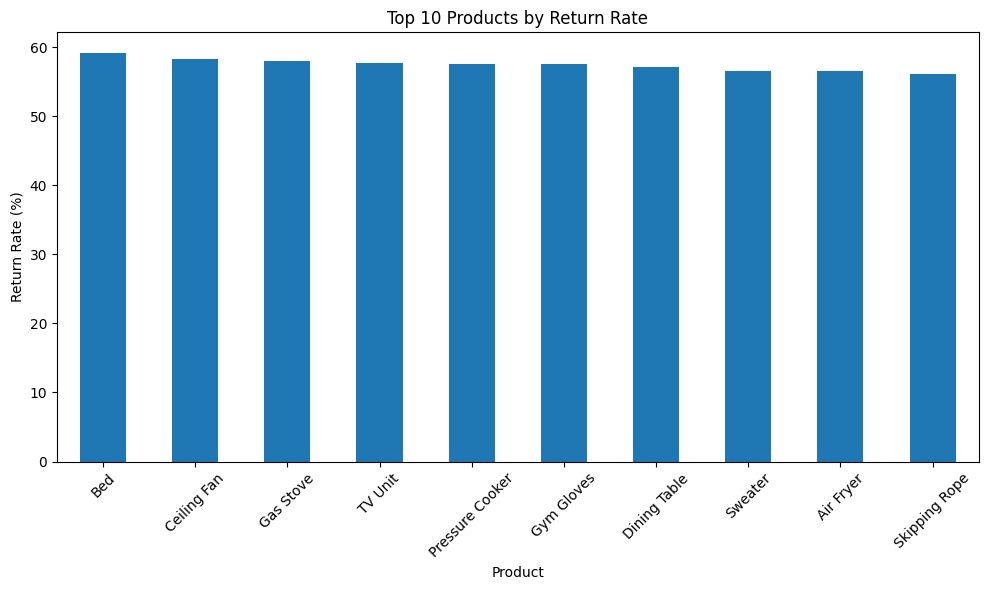

In [81]:
print(df_clean['Returned'].value_counts(dropna=False))
print(df_clean['Returned'].unique())

total_records = len(df_clean)

returned_records = (df_clean['Returned'] == 'Yes').sum()

return_rate = (returned_records / total_records) * 100

print("Total Records:", total_records)
print("Returned Records:", returned_records)
print("Overall Return Rate:", round(return_rate, 2), "%")



return_analysis = df_clean.groupby('Product_Name').agg(
    Total_Orders=('Order_ID', 'count'),
    Returned_Orders=('Returned', lambda x: (x == 'Yes').sum())
)

return_analysis['Return_Rate'] = (
    return_analysis['Returned_Orders'] /
    return_analysis['Total_Orders'] * 100
).round(2)

return_analysis = return_analysis.sort_values(
    'Return_Rate',
    ascending=False
)

print(return_analysis.head(10))

top_return_products = return_analysis.head(10)

plt.figure(figsize=(10, 6))

top_return_products['Return_Rate'].plot(kind='bar')

plt.xlabel('Product')
plt.ylabel('Return Rate (%)')
plt.title('Top 10 Products by Return Rate')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Step 12 — Conclusion


The Retail Sales Analytics project combines data cleaning,
exploratory analysis, machine learning, customer segmentation,
and product performance analysis to generate useful business insights.

The analysis can help businesses understand sales performance,
identify valuable customer groups, evaluate product profitability,
and identify products with high return rates.

The Random Forest model provides a basis for sales prediction,
while RFM and K-Means provide customer segmentation capabilities.